In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

file_path = 'Данные для кейса по ПА.xlsx'
df_users = pd.read_excel(file_path, sheet_name='Пользователи')
df_payments = pd.read_excel(file_path, sheet_name='Платежи')


# Предобработка данных
df_users = df_users.dropna(subset=['user_id', 'group', 'city'])

df_users = df_users[(df_users['age'] > 0) & (df_users['age'] < 100)]

df_payments = df_payments.dropna(subset=['user_id'])

# Рассчитываем воронку по пользователям, берем максимальное значение, т.к. попыток может быть несколько
df_user_payments = df_payments.groupby('user_id').agg({
    'step1_opened': lambda x: x.notnull().max(),
    'step4_success': lambda x: x.notnull().max()
}).reset_index()

df_user_payments.columns = ['user_id', 'has_step1', 'has_step4']

df_merged = df_user_payments.merge(df_users, on='user_id', how='inner')

df_active_users = df_merged[df_merged['has_step1'] == True]


summary = df_active_users.groupby('group').agg(
    total_users=('user_id', 'count'),
    success_users=('has_step4', 'sum')
).reset_index()

summary['conversion'] = summary['success_users'] / summary['total_users']

print("----- РЕЗУЛЬТАТЫ А/Б ТЕСТА -----")
print(summary.to_string(index=False))


count = summary['success_users'].values
nobs = summary['total_users'].values

stat, pval = proportions_ztest(count, nobs)
print("\n----- СТАТИСТИЧЕСКИЙ ТЕСТ -----")
print(f"Z-статистика: {stat:.4f}")
print(f"p-value: {pval:.5f}")
print("\n-------------------------------")
if pval < 0.05:
    print("Результат СТАТИСТИЧЕСКИ СИГНИФИКАНТЕН. Различия между группами реальны.")
else:
    print("Результат НЕ СИГНИФИКАНТЕН. Различия могут быть случайными.")


----- РЕЗУЛЬТАТЫ А/Б ТЕСТА -----
group  total_users  success_users  conversion
    A          750            493    0.657333
    B          750            603    0.804000

----- СТАТИСТИЧЕСКИЙ ТЕСТ -----
Z-статистика: -6.4024
p-value: 0.00000

-------------------------------
Результат СТАТИСТИЧЕСКИ СИГНИФИКАНТЕН. Различия между группами реальны.


/tmp/ipykernel_4785/534449423.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Группа A\n(Контроль)', 'Группа B\n(Новая форма)'], fontsize=11)


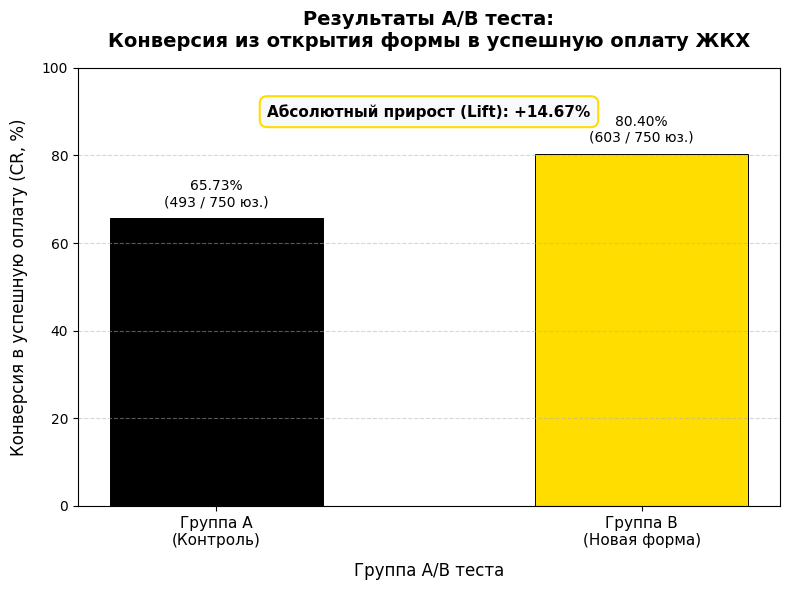

In [9]:
# Визуализация
groups = summary['group'].values
conversions = summary['conversion'].values * 100
totals = summary['total_users'].values
successes = summary['success_users'].values

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#000000', '#ffdd00']

bars = ax.bar(groups, conversions, color=colors, width=0.5, edgecolor='black', linewidth=0.7)

ax.set_ylabel('Конверсия в успешную оплату (CR, %)', fontsize=12, labelpad=10)
ax.set_xlabel('Группа А/В теста', fontsize=12, labelpad=10)
ax.set_title('Результаты A/B теста:\nКонверсия из открытия формы в успешную оплату ЖКХ',
             fontsize=14, pad=15, fontweight='bold')

ax.set_ylim(0, 100)
ax.set_xticklabels(['Группа A\n(Контроль)', 'Группа B\n(Новая форма)'], fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar, total, success, conv in zip(bars, totals, successes, conversions):
    height = bar.get_height()

    label_text = f'{conv:.2f}%\n({success} / {total} юз.)'

    ax.text(
        bar.get_x() + bar.get_width() / 2, # Координата X — центр столбца
        height + 2,                        # Координата Y — чуть выше вершины
        label_text,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold' if bar.get_facecolor() == (46/255, 204/255, 113/255, 1.0) else 'normal'
    )

lift = conversions[1] - conversions[0]
ax.text(0.5, 90, f'Абсолютный прирост (Lift): +{lift:.2f}%',
        ha='center', va='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#ffdd00', lw=1.5))

plt.tight_layout()
plt.show()


=== КОНВЕРСИЯ ПО СЕГМЕНТАМ ===
device_type group  total_users  success_users  conversion_pct
    android     A          406            262       64.532020
    android     B          369            295       79.945799
        ios     A          344            231       67.151163
        ios     B          381            308       80.839895

----- СРАВНЕНИЕ ПРИРОСТА (LIFT) -----
group                A          B  absolute_lift_pp  relative_lift_pct
device_type                                                           
android      64.532020  79.945799         15.413780          23.885475
ios          67.151163  80.839895         13.688732          20.384952

Вывод: Конверсия выросла больше для пользователей ANDROID (прирост на +15.41 п.п.)


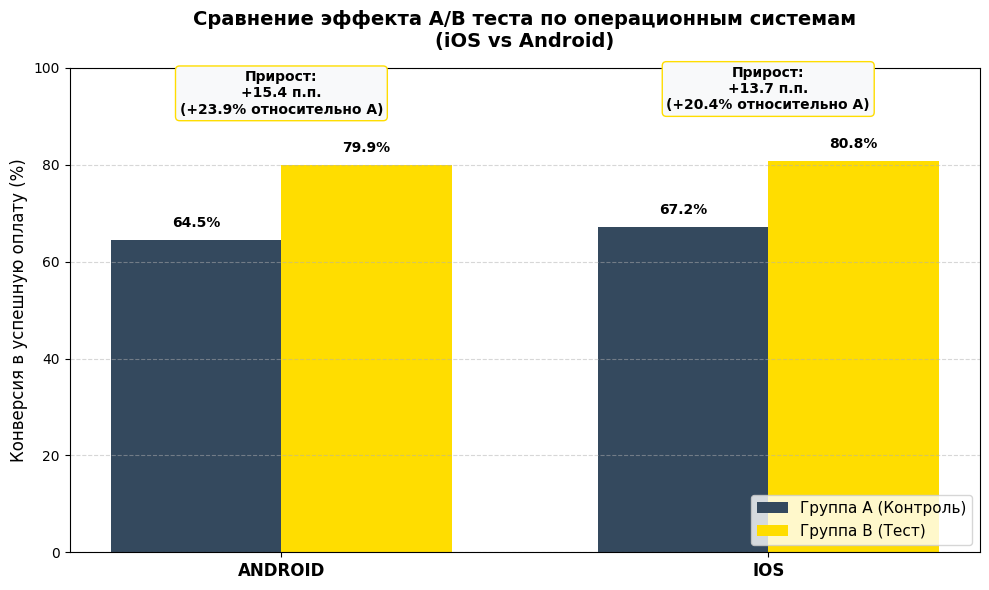

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

file_path = 'Данные для кейса по ПА.xlsx'
df_users = pd.read_excel(file_path, sheet_name='Пользователи')
df_payments = pd.read_excel(file_path, sheet_name='Платежи')

# Предобработка данных
df_users = df_users.dropna(subset=['user_id', 'group', 'city'])
df_users = df_users[(df_users['age'] > 0) & (df_users['age'] < 100)]
df_payments = df_payments.dropna(subset=['user_id'])

# Агрегируем шаги на уровне пользователя мах значение
df_user_payments = df_payments.groupby('user_id').agg({
    'step1_opened': lambda x: x.notnull().max(),
    'step4_success': lambda x: x.notnull().max()
}).reset_index()

df_user_payments.columns = ['user_id', 'has_step1', 'has_step4']

# Объединяем с профилями пользователей и оставляем только тех, кто открыл форму
df_merged = df_user_payments.merge(df_users, on='user_id', how='inner')
df_active_users = df_merged[df_merged['has_step1'] == True]

# Группируем данные одновременно по device_type и group
segment_summary = df_active_users.groupby(['device_type', 'group']).agg(
    total_users=('user_id', 'count'),
    success_users=('has_step4', 'sum')
).reset_index()

# Считаем конверсию для каждого сегмента
segment_summary['conversion_pct'] = (segment_summary['success_users'] / segment_summary['total_users']) * 100

print("=== КОНВЕРСИЯ ПО СЕГМЕНТАМ ===")
print(segment_summary.to_string(index=False))

# Вычисляем, где прирост (Lift) оказался больше
# Разворачиваем таблицу для удобного сравнения групп А и В
pivot_segments = segment_summary.pivot(index='device_type', columns='group', values='conversion_pct')
# Считаем абсолютный прирост в процентных пунктах (п.п.)
pivot_segments['absolute_lift_pp'] = pivot_segments['B'] - pivot_segments['A']
# Считаем относительный прирост (на сколько процентов выросла конверсия относительно базы А)
pivot_segments['relative_lift_pct'] = (pivot_segments['B'] - pivot_segments['A']) / pivot_segments['A'] * 100

print("\n----- СРАВНЕНИЕ ПРИРОСТА (LIFT) -----")
print(pivot_segments[['A', 'B', 'absolute_lift_pp', 'relative_lift_pct']])

# Определяем победителя автоматическим кодом
best_device = pivot_segments['absolute_lift_pp'].idxmax()
max_lift = pivot_segments['absolute_lift_pp'].max()
print(f"\nВывод: Конверсия выросла больше для пользователей {best_device.upper()} (прирост на +{max_lift:.2f} п.п.)")

# Отрисовка графика
fig, ax = plt.subplots(figsize=(10, 6))

devices = pivot_segments.index.values
x_positions = np.arange(len(devices))
bar_width = 0.35

# Столбцы для групп А и В
bars_A = ax.bar(x_positions - bar_width/2, pivot_segments['A'], bar_width, label='Группа A (Контроль)', color='#34495e')
bars_B = ax.bar(x_positions + bar_width/2, pivot_segments['B'], bar_width, label='Группа B (Тест)', color='#ffdd00')

# Оформление графика
ax.set_ylabel('Конверсия в успешную оплату (%)', fontsize=12)
ax.set_title('Сравнение эффекта А/В теста по операционным системам\n(iOS vs Android)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_positions)
ax.set_xticklabels([d.upper() for d in devices], fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=11)

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

add_labels(bars_A)
add_labels(bars_B)

# Добавляем стрелки или текстовые плашки с чистым эффектом (Lift) над парами столбцов
for idx, device in enumerate(devices):
    abs_lift = pivot_segments.loc[device, 'absolute_lift_pp']
    rel_lift = pivot_segments.loc[device, 'relative_lift_pct']
    ax.text(idx, max(pivot_segments.loc[device, ['A', 'B']]) + 10,
            f'Прирост:\n+{abs_lift:.1f} п.п.\n(+{rel_lift:.1f}% относительно А)',
            ha='center', va='bottom', fontsize=10, color='#000000', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f8f9fa', edgecolor='#ffdd00', lw=1))

plt.tight_layout()
plt.show()